In [1]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d karakaggle/kaggle-cat-vs-dog-dataset

Dataset URL: https://www.kaggle.com/datasets/karakaggle/kaggle-cat-vs-dog-dataset
License(s): unknown
100% 787M/787M [00:08<00:00, 94.1MB/s]



In [4]:
!unzip -q kaggle-cat-vs-dog-dataset.zip

In [5]:
import os

for root, dirs, files in os.walk("/content"):
    if "PetImages" in root:
        print(root)

/content/kagglecatsanddogs_3367a/PetImages
/content/kagglecatsanddogs_3367a/PetImages/Cat
/content/kagglecatsanddogs_3367a/PetImages/Dog


In [6]:
!pip install -q scikit-image

In [7]:
import os
import cv2
import joblib
import random
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [8]:
# Dataset location

DATASET_PATH = "/content/kagglecatsanddogs_3367a/PetImages"

CAT_PATH = os.path.join(DATASET_PATH, "Cat")
DOG_PATH = os.path.join(DATASET_PATH, "Dog")

# Image settings

IMG_SIZE = 128
MAX_IMAGES = 2000

# Lists to store data

features = []
labels = []
images = []
image_paths = []

# Class names

classes = {
    "Cat": 0,
    "Dog": 1
}

In [9]:
def load_images(folder_path, label, max_images):
    """
    Loads images from a folder, preprocesses them,
    extracts HOG features, and stores the results.
    """

    count = 0

    image_files = os.listdir(folder_path)

    random.shuffle(image_files)

    for file_name in image_files:

        if count >= max_images:
            break

        image_path = os.path.join(folder_path, file_name)

        image = cv2.imread(image_path)

        # Skip corrupted images

        if image is None:
            continue

        try:

            # Resize image

            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

            # Convert to grayscale

            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            # Extract HOG features

            hog_features = hog(
                gray,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                block_norm="L2-Hys"
            )

            # Store everything

            features.append(hog_features)
            labels.append(label)
            images.append(image)
            image_paths.append(image_path)

            count += 1

        except Exception:
            continue

    print(f"Loaded {count} images from {os.path.basename(folder_path)}")

In [10]:
print("Loading images...\n")

load_images(CAT_PATH, 0, MAX_IMAGES)
load_images(DOG_PATH, 1, MAX_IMAGES)

print("\nDataset loaded successfully.")

Loading images...

Loaded 2000 images from Cat
Loaded 2000 images from Dog

Dataset loaded successfully.


In [11]:
features = np.array(features)
labels = np.array(labels)
images = np.array(images)
image_paths = np.array(image_paths)

In [12]:
cat_count = np.sum(labels == 0)
dog_count = np.sum(labels == 1)

print("=" * 40)
print("Dataset Statistics")
print("=" * 40)

print(f"Total Images : {len(labels)}")
print(f"Cat Images   : {cat_count}")
print(f"Dog Images   : {dog_count}")
print(f"Image Size   : {IMG_SIZE} x {IMG_SIZE}")
print(f"HOG Features : {features.shape[1]}")

Dataset Statistics
Total Images : 4000
Cat Images   : 2000
Dog Images   : 2000
Image Size   : 128 x 128
HOG Features : 8100


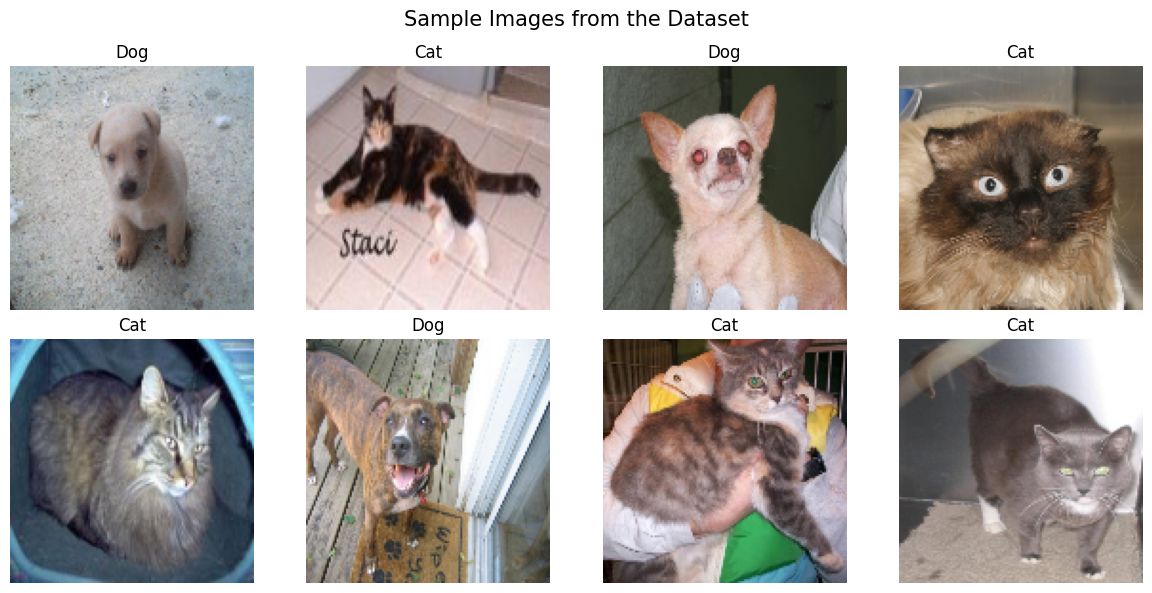

In [13]:
plt.figure(figsize=(12, 6))

sample_indices = random.sample(range(len(images)), 8)

for i, index in enumerate(sample_indices):

    plt.subplot(2, 4, i + 1)

    plt.imshow(cv2.cvtColor(images[index], cv2.COLOR_BGR2RGB))

    title = "Cat" if labels[index] == 0 else "Dog"

    plt.title(title)

    plt.axis("off")

plt.suptitle("Sample Images from the Dataset", fontsize=15)

plt.tight_layout()

plt.show()

In [14]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test, train_images, test_images, train_paths, test_paths = train_test_split(
    features,
    labels,
    images,
    image_paths,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("=" * 40)
print("Dataset Split")
print("=" * 40)

print(f"Training Images : {len(X_train)}")
print(f"Testing Images  : {len(X_test)}")

Dataset Split
Training Images : 3200
Testing Images  : 800


In [15]:
print("=" * 40)
print("Training Linear SVM...")
print("=" * 40)

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train, y_train)

print("\nModel training completed successfully.")

Training Linear SVM...

Model training completed successfully.


In [16]:
predictions = svm_model.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, predictions)

print("=" * 40)
print("Model Performance")
print("=" * 40)

print(f"Accuracy : {accuracy * 100:.2f}%")

Model Performance
Accuracy : 66.50%


Classification Report
              precision    recall  f1-score   support

         Cat       0.66      0.69      0.67       400
         Dog       0.67      0.64      0.66       400

    accuracy                           0.67       800
   macro avg       0.67      0.67      0.66       800
weighted avg       0.67      0.67      0.66       800



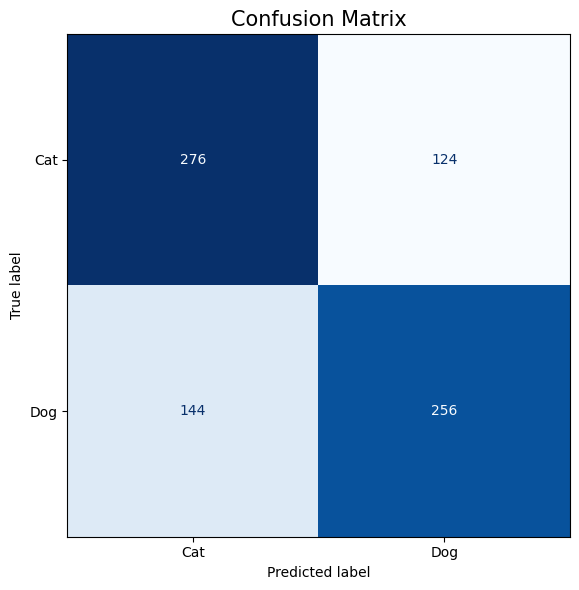

In [19]:
print("=" * 40)
print("Classification Report")
print("=" * 40)

print(
    classification_report(
        y_test,
        predictions,
        target_names=["Cat", "Dog"]
    )
)
cm = confusion_matrix(y_test, predictions)

fig, ax = plt.subplots(figsize=(6,6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

plt.title("Confusion Matrix", fontsize=15)
plt.tight_layout()
plt.show()

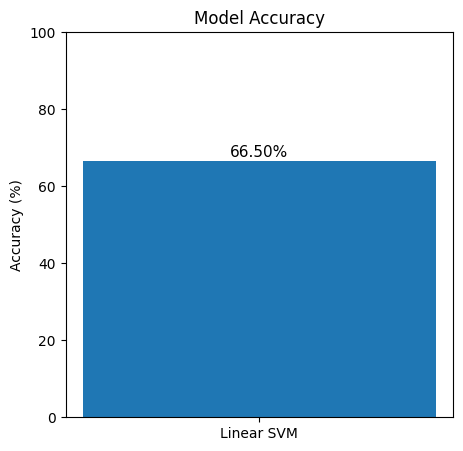

In [20]:
plt.figure(figsize=(5, 5))

plt.bar(
    ["Linear SVM"],
    [accuracy * 100]
)

plt.ylim(0, 100)

plt.ylabel("Accuracy (%)")

plt.title("Model Accuracy")

plt.text(
    0,
    accuracy * 100 + 1,
    f"{accuracy * 100:.2f}%",
    ha="center",
    fontsize=11
)

plt.show()

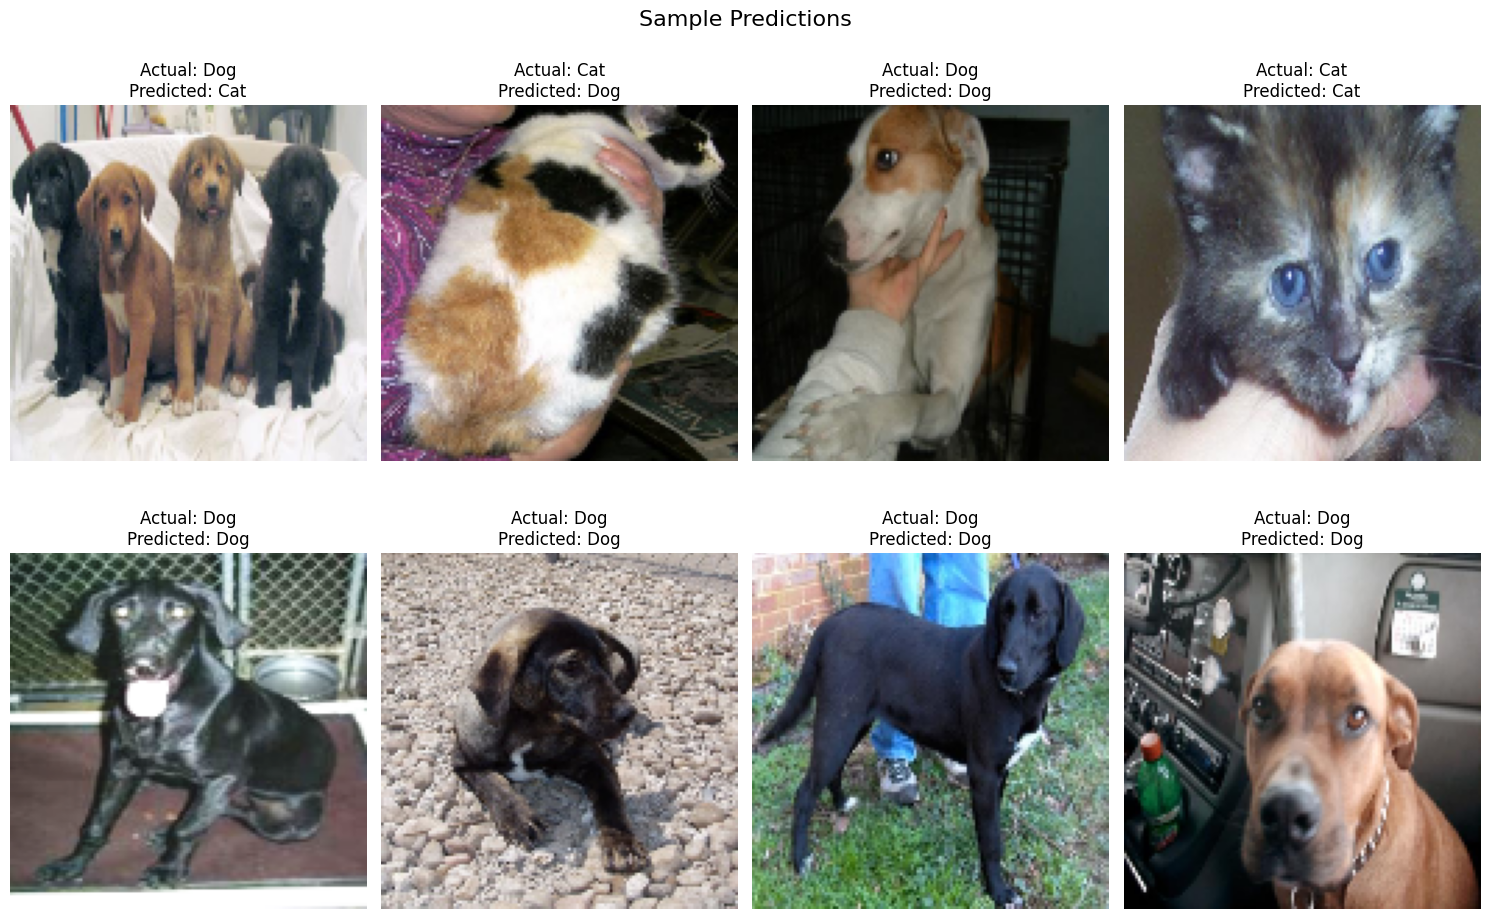

In [21]:
plt.figure(figsize=(15, 10))

sample_indices = random.sample(range(len(X_test)), 8)

for i, index in enumerate(sample_indices):

    plt.subplot(2, 4, i + 1)

    plt.imshow(cv2.cvtColor(test_images[index], cv2.COLOR_BGR2RGB))

    actual = "Cat" if y_test[index] == 0 else "Dog"
    predicted = "Cat" if predictions[index] == 0 else "Dog"

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")

    plt.axis("off")

plt.suptitle("Sample Predictions", fontsize=16)

plt.tight_layout()

plt.show()

In [22]:
joblib.dump(svm_model, "svm_cat_dog_model.pkl")

print("Model saved successfully as svm_cat_dog_model.pkl")

Model saved successfully as svm_cat_dog_model.pkl
